# Implementación de un Filtro de Suavizado
Diseño de un filtro de promedio que recorre la imagen utilizando ventanas de 3×3 píxeles para reducir ruido y suavizar transiciones de color.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 6)
print("librerías cargadas.")

librerías cargadas.


## Paso 1: Cargar la imagen original

subir imagen:


Saving Gaussian-noise-Nm0-s-2-01-applied-to-the-test-image-of-Figure-1-Colour-values.jpg to Gaussian-noise-Nm0-s-2-01-applied-to-the-test-image-of-Figure-1-Colour-values (1).jpg
dimensiones de la imagen: (500, 500, 3)
alto: 500px, ancho: 500px, canales: 3 (R, G, B)


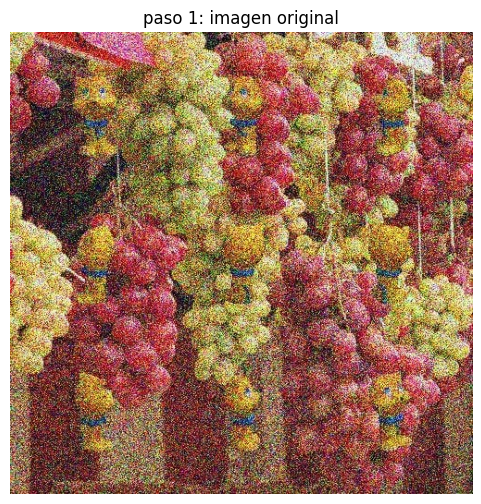

In [8]:
from google.colab import files

print("subir imagen:")
uploaded = files.upload()

for fn in uploaded.keys():
    img_bgr = cv2.imread(fn)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"dimensiones de la imagen: {img_rgb.shape}")
print(f"alto: {img_rgb.shape[0]}px, ancho: {img_rgb.shape[1]}px, canales: {img_rgb.shape[2]} (R, G, B)")

plt.imshow(img_rgb)
plt.title('paso 1: imagen original')
plt.axis('off')
plt.show()

## Paso 2: Separar los canales de color
Una imagen a color está compuesta por 3 capas (Rojo, Verde, Azul). El filtro se aplica a cada canal por separado.

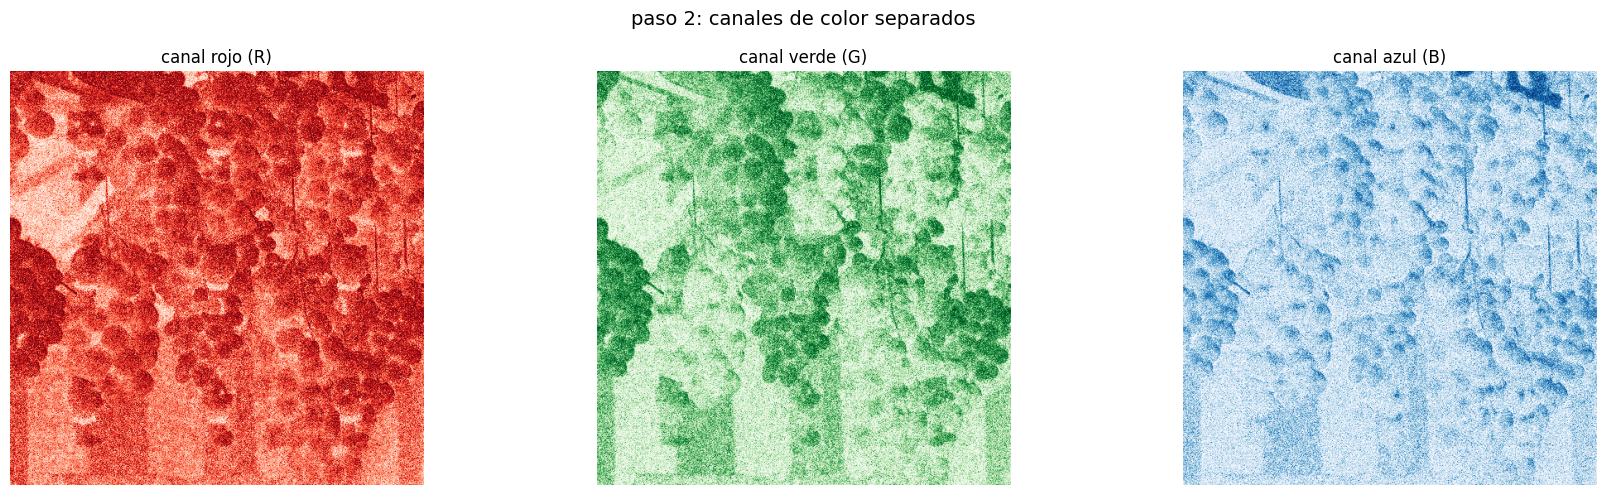

In [3]:
# separar los 3 canales de color
canal_r = img_rgb[:, :, 0]
canal_g = img_rgb[:, :, 1]
canal_b = img_rgb[:, :, 2]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(canal_r, cmap='Reds')
axs[0].set_title('canal rojo (R)')
axs[0].axis('off')

axs[1].imshow(canal_g, cmap='Greens')
axs[1].set_title('canal verde (G)')
axs[1].axis('off')

axs[2].imshow(canal_b, cmap='Blues')
axs[2].set_title('canal azul (B)')
axs[2].axis('off')

plt.suptitle('paso 2: canales de color separados', fontsize=14)
plt.tight_layout()
plt.show()

## Paso 3: Diseñar el kernel (ventana) de 3×3
El kernel es una matriz de 3×3 donde cada valor es $\frac{1}{9}$. Cuando esta ventana recorre la imagen, reemplaza cada píxel por el **promedio** de él mismo y sus 8 vecinos.

kernel de suavizado 3x3:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

cada valor = 1/9 ≈ 0.1111
la suma de todos los valores = 1.0


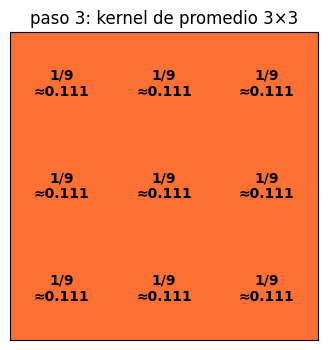

In [4]:
# diseño del kernel de promedio 3x3
kernel_3x3 = np.ones((3, 3), np.float32) / 9

print("kernel de suavizado 3x3:")
print(kernel_3x3)
print(f"\ncada valor = 1/9 ≈ {1/9:.4f}")
print(f"la suma de todos los valores = {kernel_3x3.sum():.1f}")

# visualizar el kernel
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(kernel_3x3, cmap='YlOrRd', vmin=0, vmax=0.2)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'1/9\n≈{kernel_3x3[i,j]:.3f}', ha='center', va='center', fontsize=10, fontweight='bold')
ax.set_title('paso 3: kernel de promedio 3×3')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## Paso 4: Demostración del funcionamiento en una zona pequeña
Tomamos un parche de 5×5 píxeles para mostrar cómo la ventana 3×3 calcula el promedio al recorrer la imagen.

valores originales del parche 5x5 (canal rojo):
[[133 129  88  88 166]
 [202 139 145 102 134]
 [198 110 135 140 121]
 [103 106  97 100 103]
 [101 108  56 120  70]]

vecinos 3x3 alrededor del pixel [1,1]:
[[133 129  88]
 [202 139 145]
 [198 110 135]]

promedio = (133 + 129 + 88 + 202 + 139 + 145 + 198 + 110 + 135) / 9 = 142.1
el pixel [1,1] pasa de 139 → 142


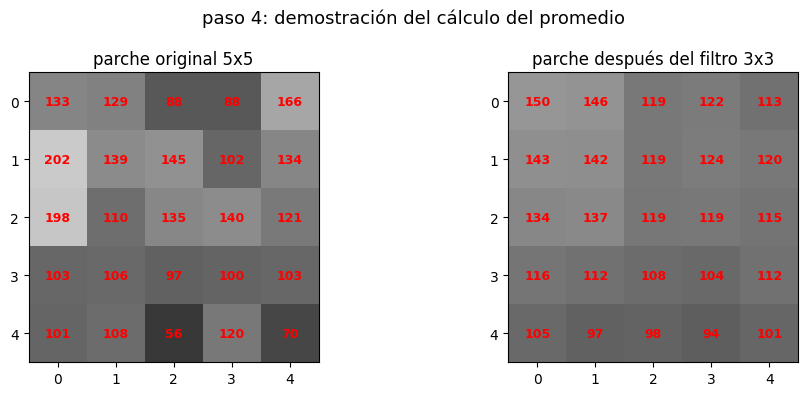

In [5]:
# extraer un parche pequeño del canal rojo para demostrar
h, w = canal_r.shape
cy, cx = h // 2, w // 2
parche = canal_r[cy:cy+5, cx:cx+5].astype(float)

print("valores originales del parche 5x5 (canal rojo):")
print(parche.astype(int))

# calcular manualmente el promedio para el pixel central [1,1]
vecinos = parche[0:3, 0:3]
promedio = vecinos.mean()

print(f"\nvecinos 3x3 alrededor del pixel [1,1]:")
print(vecinos.astype(int))
print(f"\npromedio = ({' + '.join(str(int(v)) for v in vecinos.flatten())}) / 9 = {promedio:.1f}")
print(f"el pixel [1,1] pasa de {int(parche[1,1])} → {int(promedio)}")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(parche, cmap='gray', vmin=0, vmax=255)
for i in range(5):
    for j in range(5):
        axs[0].text(j, i, f'{int(parche[i,j])}', ha='center', va='center', color='red', fontsize=9, fontweight='bold')
axs[0].set_title('parche original 5x5')

# aplicar filtro al parche
parche_filtrado = cv2.filter2D(parche, -1, kernel_3x3)
axs[1].imshow(parche_filtrado, cmap='gray', vmin=0, vmax=255)
for i in range(5):
    for j in range(5):
        axs[1].text(j, i, f'{int(parche_filtrado[i,j])}', ha='center', va='center', color='red', fontsize=9, fontweight='bold')
axs[1].set_title('parche después del filtro 3x3')

plt.suptitle('paso 4: demostración del cálculo del promedio', fontsize=13)
plt.tight_layout()
plt.show()

## Paso 5: Aplicar el filtro a la imagen completa
La función `cv2.filter2D` desliza el kernel por toda la imagen, calculando el promedio en cada posición.

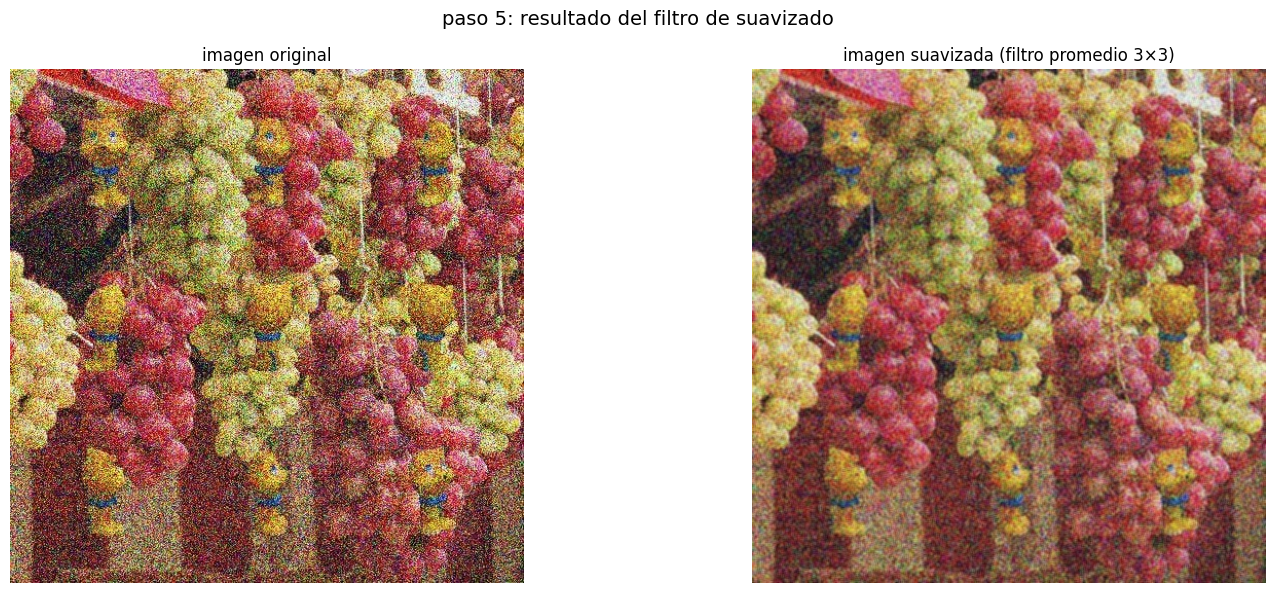

In [6]:
# aplicar el filtro a la imagen completa en color
img_suavizada = cv2.filter2D(img_rgb, -1, kernel_3x3)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_suavizada)
plt.title('imagen suavizada (filtro promedio 3×3)')
plt.axis('off')

plt.suptitle('paso 5: resultado del filtro de suavizado', fontsize=14)
plt.tight_layout()
plt.show()